# 📘 Projeto Real: Análise de Vendas Online

Este notebook mostra um fluxo completo de análise de vendas online, desde o pré-processamento, limpeza, estatísticas descritivas, distribuições até visualizações.

In [1]:

# Importar bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de estilo
%matplotlib inline
sns.set(style="whitegrid", palette="muted", font_scale=1.1)


## 1) Carregar Dataset

In [2]:

# Carregar dataset
# Exemplo: df = pd.read_excel("Online Retail.xlsx")
# df = pd.read_csv("online_retail.csv", encoding='latin1')

# Para demonstração, vamos simular um dataset pequeno caso não tenha o arquivo real
# (Se você tiver o arquivo real, basta descomentar a linha acima)
data = {
    'InvoiceNo': ['10001','10002','10003','10004','10005'],
    'StockCode': ['A1','A2','A3','A4','A5'],
    'Description': ['Produto A','Produto B','Produto C','Produto D','Produto E'],
    'Quantity': [10, 5, 20, 3, 7],
    'InvoiceDate': pd.date_range(start='2023-01-01', periods=5, freq='M'),
    'UnitPrice': [5.0, 10.0, 2.5, 20.0, 7.5],
    'CustomerID': [12345, 12346, 12347, 12348, 12349],
    'Country': ['Brazil','Brazil','Portugal','Spain','Brazil']
}
df = pd.DataFrame(data)
df.head()


C:\Users\dr_ju\AppData\Local\Temp\ipykernel_17076\2775407367.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  'InvoiceDate': pd.date_range(start='2023-01-01', periods=5, freq='M'),


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,10001,A1,Produto A,10,2023-01-31,5.0,12345,Brazil
1,10002,A2,Produto B,5,2023-02-28,10.0,12346,Brazil
2,10003,A3,Produto C,20,2023-03-31,2.5,12347,Portugal
3,10004,A4,Produto D,3,2023-04-30,20.0,12348,Spain
4,10005,A5,Produto E,7,2023-05-31,7.5,12349,Brazil


## 2) Exploração Inicial

In [3]:

print("Dimensão do dataset:", df.shape)
print("\nColunas disponíveis:", df.columns.tolist())
print("\nResumo dos dados:")
print(df.info())
print("\nValores nulos por coluna:")
print(df.isna().sum())


Dimensão do dataset: (5, 8)

Colunas disponíveis: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Resumo dos dados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    5 non-null      object        
 1   StockCode    5 non-null      object        
 2   Description  5 non-null      object        
 3   Quantity     5 non-null      int64         
 4   InvoiceDate  5 non-null      datetime64[ns]
 5   UnitPrice    5 non-null      float64       
 6   CustomerID   5 non-null      int64         
 7   Country      5 non-null      object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 452.0+ bytes
None

Valores nulos por coluna:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID    

## 3) Pré-processamento e Limpeza

In [4]:

# Converter coluna de data
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Criar coluna de valor total
df['TotalValue'] = df['Quantity'] * df['UnitPrice']

# Remover cancelamentos (caso existam)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Padronizar descrições
df['Description'] = df['Description'].astype(str).str.strip()

# Remover duplicados
df = df.drop_duplicates()

print("Dataset após limpeza:", df.shape)
df.head()


Dataset após limpeza: (5, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalValue
0,10001,A1,Produto A,10,2023-01-31,5.0,12345,Brazil,50.0
1,10002,A2,Produto B,5,2023-02-28,10.0,12346,Brazil,50.0
2,10003,A3,Produto C,20,2023-03-31,2.5,12347,Portugal,50.0
3,10004,A4,Produto D,3,2023-04-30,20.0,12348,Spain,60.0
4,10005,A5,Produto E,7,2023-05-31,7.5,12349,Brazil,52.5


## 4) Estatísticas Descritivas

In [5]:

print("Estatísticas descritivas:\n")
print(df[['Quantity','UnitPrice','TotalValue']].describe())

print("\nNúmero de clientes únicos:", df['CustomerID'].nunique())
print("Número de produtos únicos:", df['Description'].nunique())
print("Receita total:", df['TotalValue'].sum())


Estatísticas descritivas:

        Quantity  UnitPrice  TotalValue
count   5.000000   5.000000    5.000000
mean    9.000000   9.000000   52.500000
std     6.670832   6.754628    4.330127
min     3.000000   2.500000   50.000000
25%     5.000000   5.000000   50.000000
50%     7.000000   7.500000   50.000000
75%    10.000000  10.000000   52.500000
max    20.000000  20.000000   60.000000

Número de clientes únicos: 5
Número de produtos únicos: 5
Receita total: 262.5


## 5) Distribuições (Histogramas)

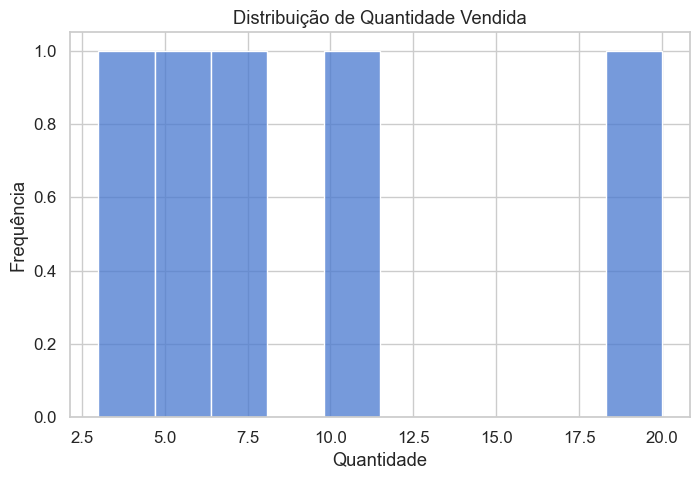

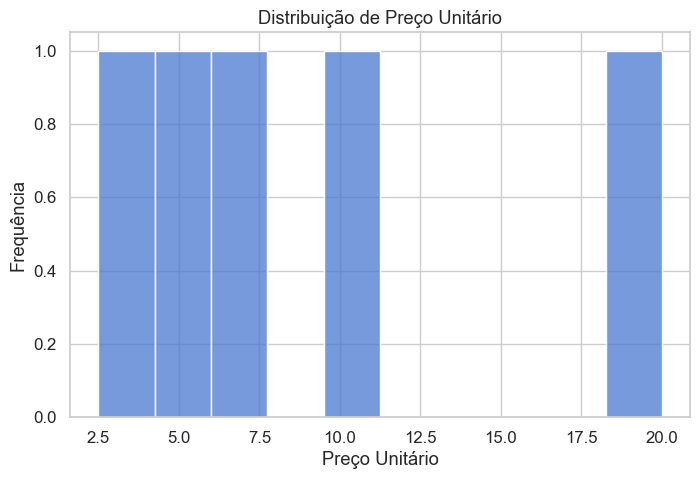

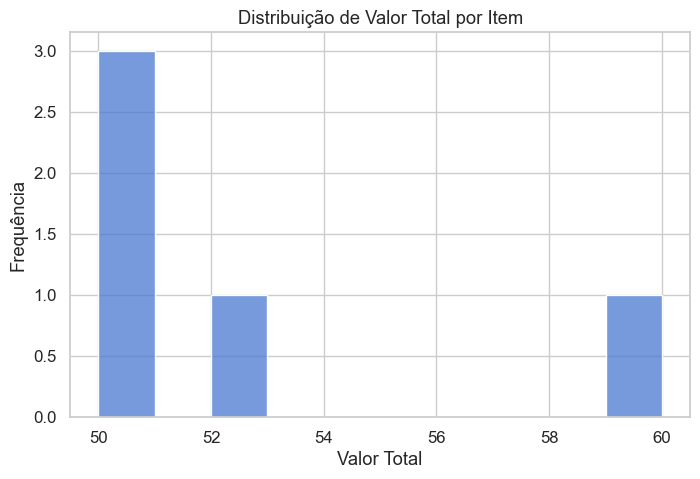

In [6]:

# Histograma da quantidade
plt.figure(figsize=(8,5))
sns.histplot(df['Quantity'], bins=10, kde=False)
plt.title("Distribuição de Quantidade Vendida")
plt.xlabel("Quantidade")
plt.ylabel("Frequência")
plt.show()

# Histograma do preço unitário
plt.figure(figsize=(8,5))
sns.histplot(df['UnitPrice'], bins=10, kde=False)
plt.title("Distribuição de Preço Unitário")
plt.xlabel("Preço Unitário")
plt.ylabel("Frequência")
plt.show()

# Histograma do valor total
plt.figure(figsize=(8,5))
sns.histplot(df['TotalValue'], bins=10, kde=False)
plt.title("Distribuição de Valor Total por Item")
plt.xlabel("Valor Total")
plt.ylabel("Frequência")
plt.show()


## 6) Análises e Visualizações

### 6.1 Receita por País

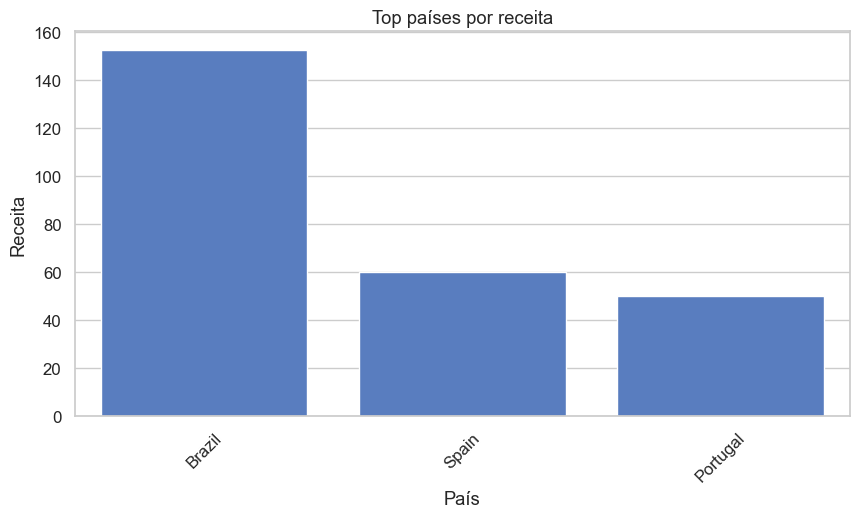

In [7]:

sales_by_country = df.groupby('Country')['TotalValue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=sales_by_country.index, y=sales_by_country.values)
plt.title("Top países por receita")
plt.xlabel("País")
plt.ylabel("Receita")
plt.xticks(rotation=45)
plt.show()


### 6.2 Evolução Mensal de Vendas

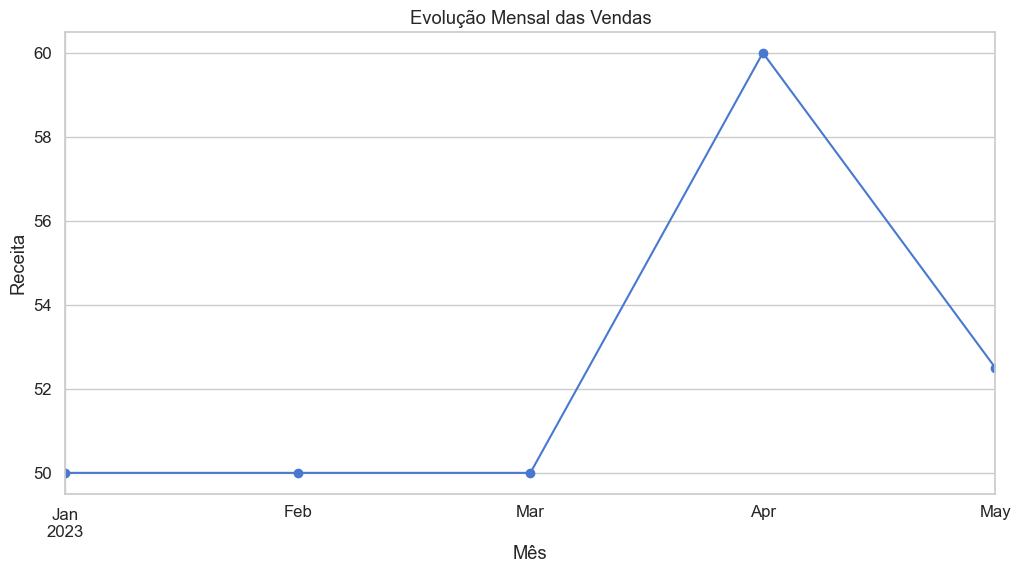

In [8]:

df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly_sales = df.groupby('Month')['TotalValue'].sum()

plt.figure(figsize=(12,6))
monthly_sales.plot(marker='o')
plt.title("Evolução Mensal das Vendas")
plt.ylabel("Receita")
plt.xlabel("Mês")
plt.grid(True)
plt.show()


### 6.3 Produtos mais Vendidos

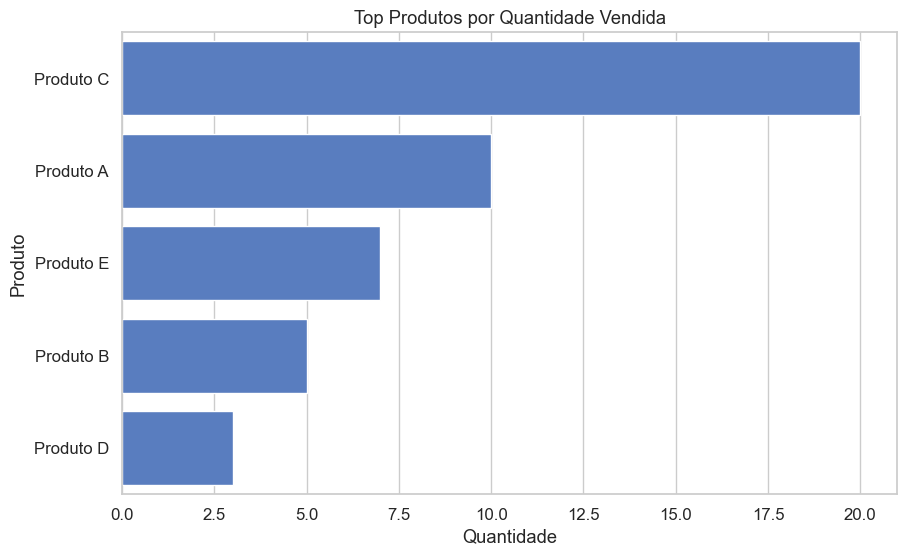

In [9]:

top_products_qty = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_products_qty.values, y=top_products_qty.index)
plt.title("Top Produtos por Quantidade Vendida")
plt.xlabel("Quantidade")
plt.ylabel("Produto")
plt.show()


### 6.4 Boxplot

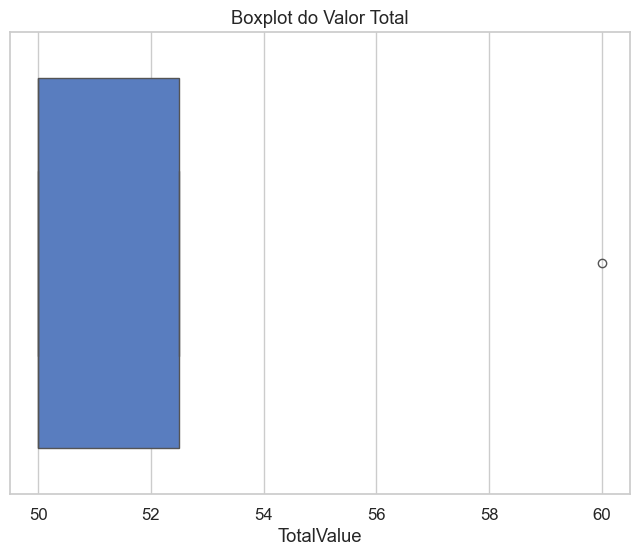

In [10]:

plt.figure(figsize=(8,6))
sns.boxplot(x=df['TotalValue'])
plt.title("Boxplot do Valor Total")
plt.show()


### 6.5 Dispersão (Preço x Quantidade)

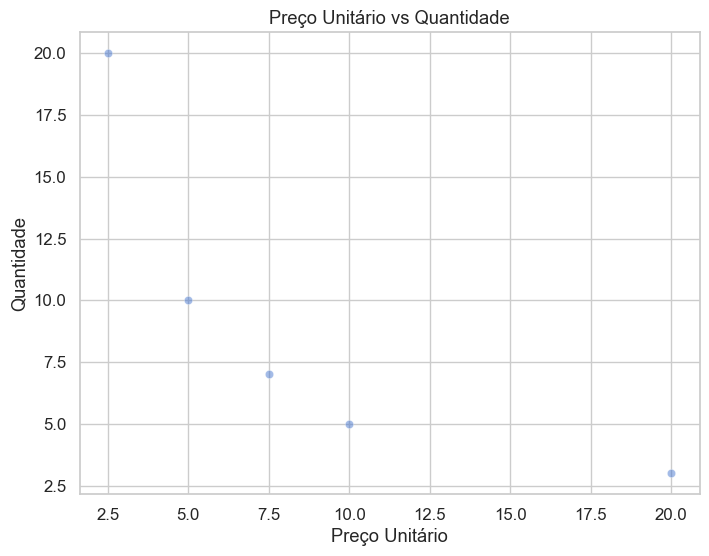

In [11]:

plt.figure(figsize=(8,6))
sns.scatterplot(x='UnitPrice', y='Quantity', data=df, alpha=0.5)
plt.title("Preço Unitário vs Quantidade")
plt.xlabel("Preço Unitário")
plt.ylabel("Quantidade")
plt.show()


### 6.6 Matriz de Correlação

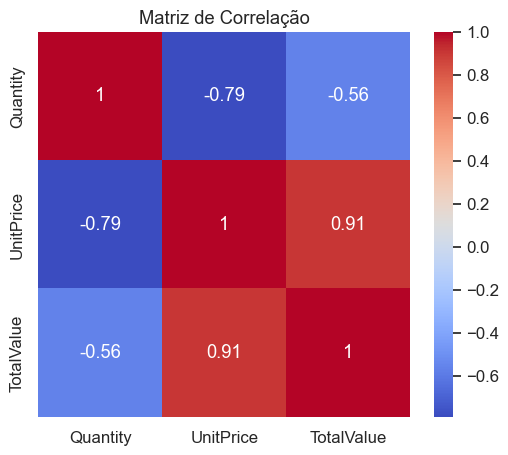

In [12]:

corr = df[['Quantity','UnitPrice','TotalValue']].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de Correlação")
plt.show()
